In [1]:
import os

FIGURES_DIR = "figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

1. Import bibliotek

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

sns.set_theme(
    style="whitegrid",
    context="paper"
)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

2. Wczytanie danych

In [3]:
path_to_data = '../data/'

all_files = []

for root, dirs, files in os.walk(path_to_data):
    for file in files:
        if file.endswith('.csv'):
            all_files.append(os.path.join(root, file))

print(f'Liczba plików CSV: {len(all_files)}')

Liczba plików CSV: 35


3. Wczytanie eksperymentów anomalnych

In [4]:
list_of_df = [
    pd.read_csv(
        file,
        sep=';',
        index_col='datetime',
        parse_dates=True
    )
    for file in all_files
    if 'anomaly-free' not in file
]
print(f'Liczba eksperymentów anomalnych: {len(list_of_df)}')

Liczba eksperymentów anomalnych: 34


4. Wczytanie danych anomaly-free

In [5]:
anomaly_free_df = pd.read_csv(
    [file for file in all_files if 'anomaly-free' in file][0],
    sep=';',
    index_col='datetime',
    parse_dates=True
)

print(anomaly_free_df.shape)

(9405, 8)


5. Podstawowe informacje o danych

In [6]:
example_df = list_of_df[0]

print(example_df.head())
print(example_df.columns)
print(example_df.shape)
print(example_df.dtypes)

                     Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  \
datetime                                                                       
2020-03-01 15:44:06           0.082065           0.133521  1.27794  0.054711   
2020-03-01 15:44:07           0.082724           0.132378  1.12118 -0.273216   
2020-03-01 15:44:08           0.081648           0.139038  1.93242  0.054711   
2020-03-01 15:44:09           0.083335           0.132742  1.25962 -0.273216   
2020-03-01 15:44:10           0.082272           0.133171  1.59773  0.054711   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  \
datetime                                                                       
2020-03-01 15:44:06      92.2562       22.2577  209.639              76.0197   
2020-03-01 15:44:07      92.0144       22.2577  221.250              76.9806   
2020-03-01 15:44:08      92.2413       22.2748  236.615              76.0197   
2020-03-01 15:44:09      92.2438       

6. Sprawdzenie brakujących danych

In [7]:
missing_values = example_df.isnull().sum()
print(missing_values)

Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0
anomaly                0
changepoint            0
dtype: int64


7. Wizualizacja sygnałów z zaznaczoną anomalią

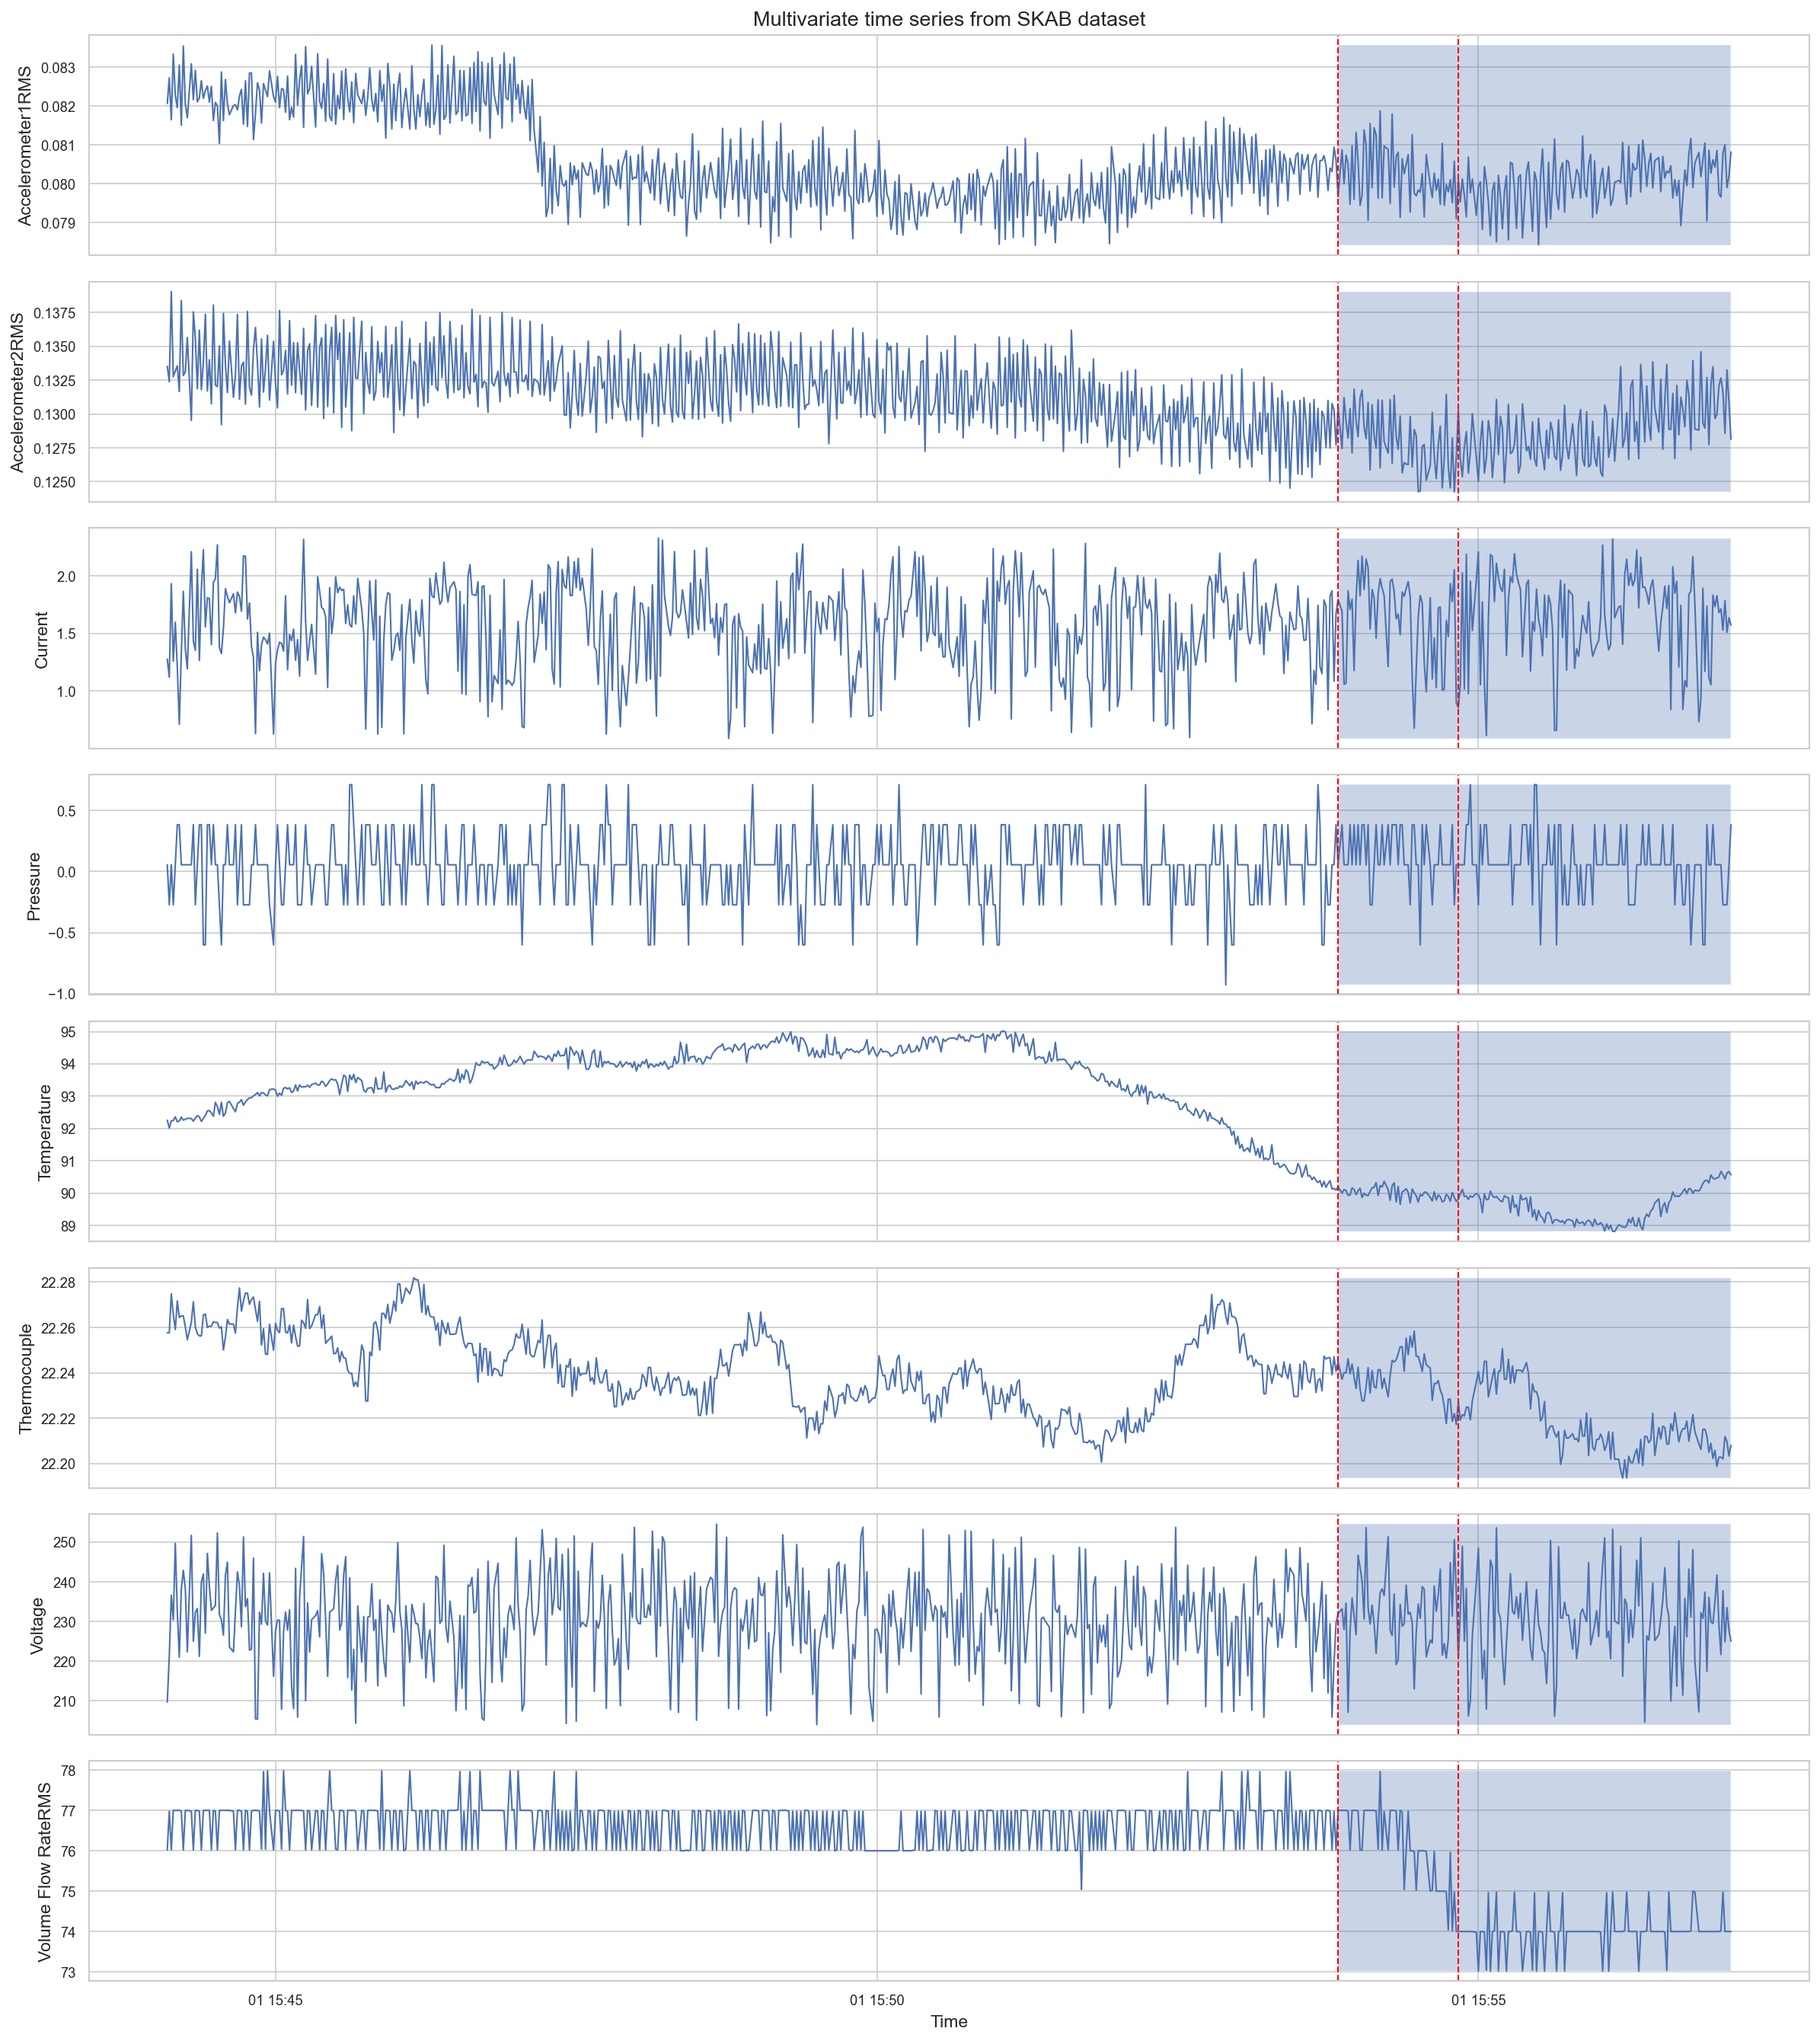

In [8]:
sensor_columns = [
    col for col in example_df.columns
    if col not in ['anomaly', 'changepoint']
]

fig, axes = plt.subplots(
    len(sensor_columns),
    1,
    figsize=(16, 18),
    sharex=True
)

anomaly_region = example_df['anomaly'] == 1

changepoints = example_df[
    example_df['changepoint'] == 1
].index

for i, column in enumerate(sensor_columns):

    axes[i].plot(
        example_df.index,
        example_df[column],
        linewidth=1
    )

    axes[i].fill_between(
        example_df.index,
        example_df[column].min(),
        example_df[column].max(),
        where=anomaly_region,
        alpha=0.3,
        label='Anomaly region'
    )

    for cp in changepoints:
        axes[i].axvline(
            cp,
            color='red',
            linestyle='--',
            linewidth=1
        )

    axes[i].set_ylabel(column)

axes[0].set_title(
    'Multivariate time series from SKAB dataset'
)

axes[-1].set_xlabel('Time')

plt.tight_layout()

plt.savefig(
    f'{FIGURES_DIR}/skab_multivariate_signals.png',
    bbox_inches='tight'
)

plt.show()

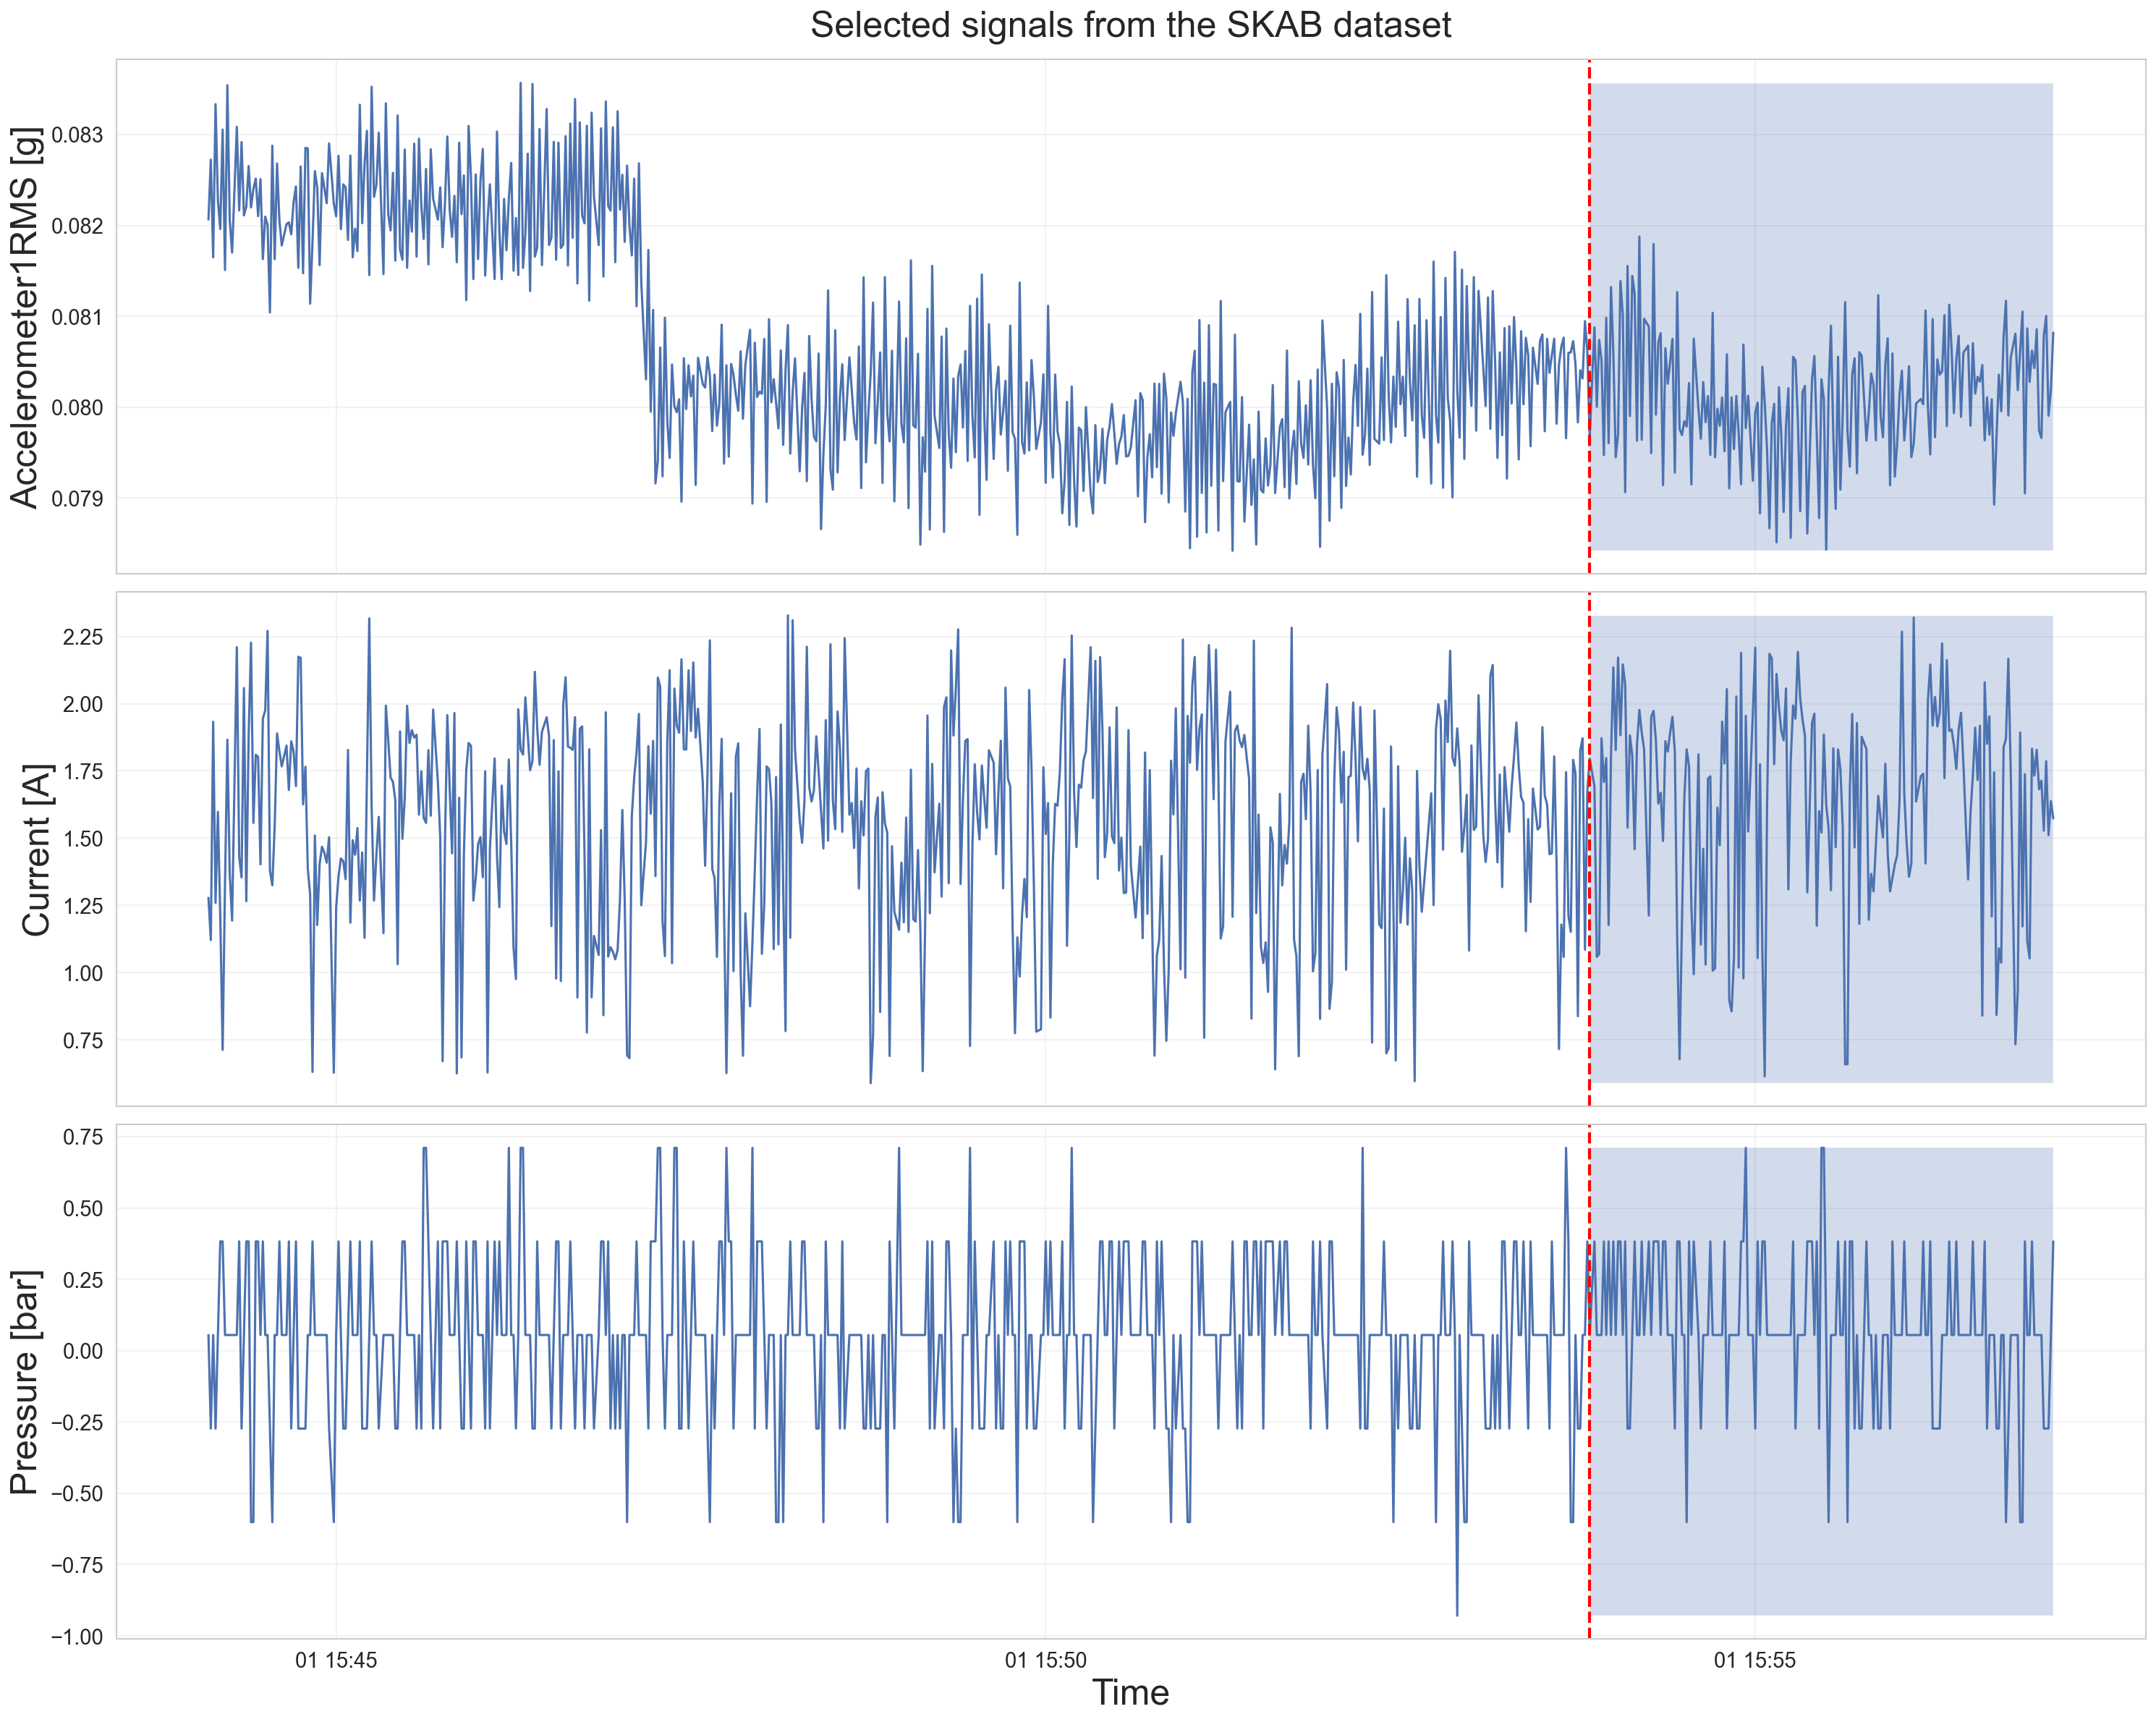

In [32]:
import matplotlib.pyplot as plt

selected_columns = [
    'Accelerometer1RMS',
    'Current',
    'Pressure'
]

# jednostki (ważne dla czytelności EDA)
units = {
    'Accelerometer1RMS': 'g',
    'Current': 'A',
    'Pressure': 'bar'
}

fig, axes = plt.subplots(
    len(selected_columns),
    1,
    figsize=(20, 16),
    sharex=True
)

anomaly_region = example_df['anomaly'] == 1
changepoints = example_df[example_df['changepoint'] == 1].index

for i, column in enumerate(selected_columns):

    axes[i].plot(
        example_df.index,
        example_df[column],
        linewidth=1.5
    )

    # zaznaczenie anomalii
    axes[i].fill_between(
        example_df.index,
        example_df[column].min(),
        example_df[column].max(),
        where=anomaly_region,
        alpha=0.25
    )

    # changepoint (pierwszy tylko jak wcześniej)
    for cp in changepoints[:1]:
        axes[i].axvline(
            cp,
            color='red',
            linestyle='--',
            linewidth=2
        )

    # 👉 jednostki w osi Y (najważniejsza zmiana)
    unit = units.get(column, '')
    axes[i].set_ylabel(
        f"{column} [{unit}]" if unit else column,
        fontsize=24
    )

    axes[i].tick_params(
        axis='both',
        labelsize=14
    )

    axes[i].grid(alpha=0.3)

axes[0].set_title(
    'Selected signals from the SKAB dataset',
    fontsize=24,
    pad=15
)

axes[-1].set_xlabel(
    'Time',
    fontsize=24
)

plt.tight_layout()
plt.show()

8. Statystyki opisowe

In [10]:
stats_df = example_df.describe().T

stats_df = stats_df[[
    'mean',
    'std',
    'min',
    'max'
]]

print(stats_df)

                           mean        std         min         max
Accelerometer1RMS      0.080549   0.001167    0.078419    0.083569
Accelerometer2RMS      0.131089   0.003030    0.124244    0.139038
Current                1.569378   0.386894    0.589101    2.328130
Pressure               0.054711   0.270437   -0.929070    0.710565
Temperature           92.567708   1.933215   88.811900   95.011400
Thermocouple          22.237863   0.018487   22.193700   22.281900
Voltage              230.246807  11.037523  203.973000  254.511000
Volume Flow RateRMS   76.157459   1.155151   73.020200   77.980600
anomaly                0.252349   0.434652    0.000000    1.000000
changepoint            0.002685   0.051778    0.000000    1.000000


9. Nierównowaga klas

In [11]:
all_anomalies = 0
all_samples = 0

for df in list_of_df:
    all_anomalies += df['anomaly'].sum()
    all_samples += len(df)

anomaly_percentage = 100 * all_anomalies / all_samples

print(f'Liczba wszystkich próbek: {all_samples}')
print(f'Liczba anomalii: {all_anomalies}')
print(f'Procent anomalii: {anomaly_percentage:.2f}%')

Liczba wszystkich próbek: 37401
Liczba anomalii: 13067.0
Procent anomalii: 34.94%


10. Macierz korelacji

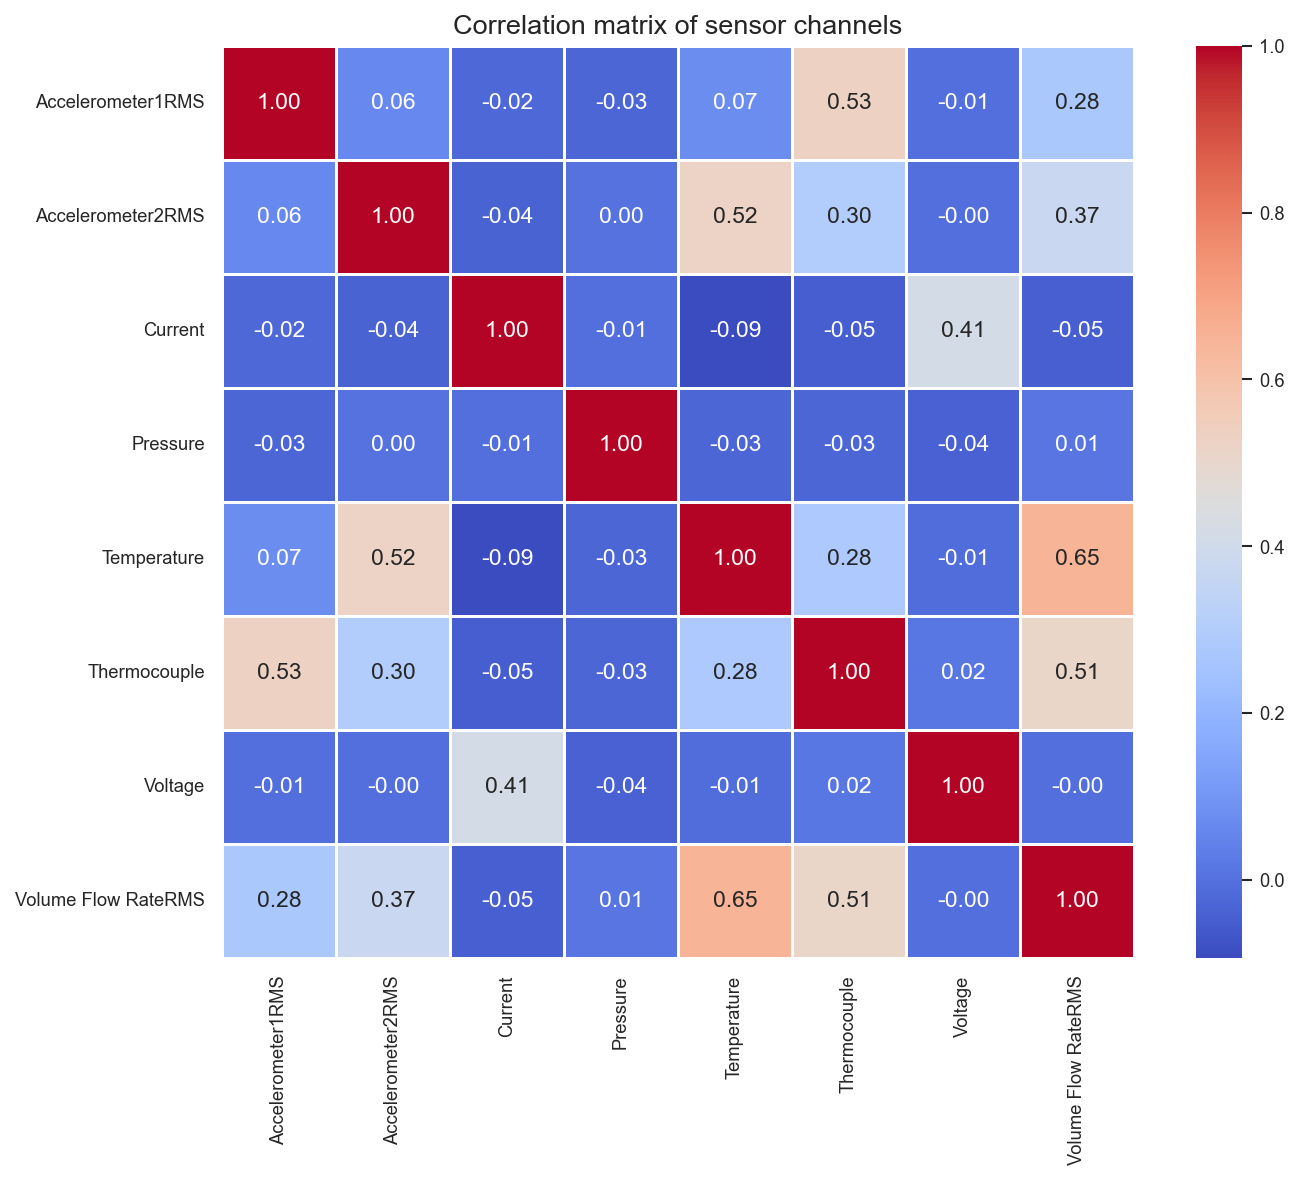

In [12]:
corr_matrix = example_df[sensor_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Correlation matrix of sensor channels')

plt.tight_layout()

plt.savefig(
    f'{FIGURES_DIR}/correlation_matrix.png',
    bbox_inches='tight'
)

plt.show()

In [13]:
corr_matrix = example_df[sensor_columns].corr()

print(corr_matrix.round(2))

                     Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  \
Accelerometer1RMS                 1.00               0.06    -0.02     -0.03   
Accelerometer2RMS                 0.06               1.00    -0.04      0.00   
Current                          -0.02              -0.04     1.00     -0.01   
Pressure                         -0.03               0.00    -0.01      1.00   
Temperature                       0.07               0.52    -0.09     -0.03   
Thermocouple                      0.53               0.30    -0.05     -0.03   
Voltage                          -0.01              -0.00     0.41     -0.04   
Volume Flow RateRMS               0.28               0.37    -0.05      0.01   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
Accelerometer1RMS           0.07          0.53    -0.01                 0.28  
Accelerometer2RMS           0.52          0.30    -0.00                 0.37  
Current                    -0.09         -

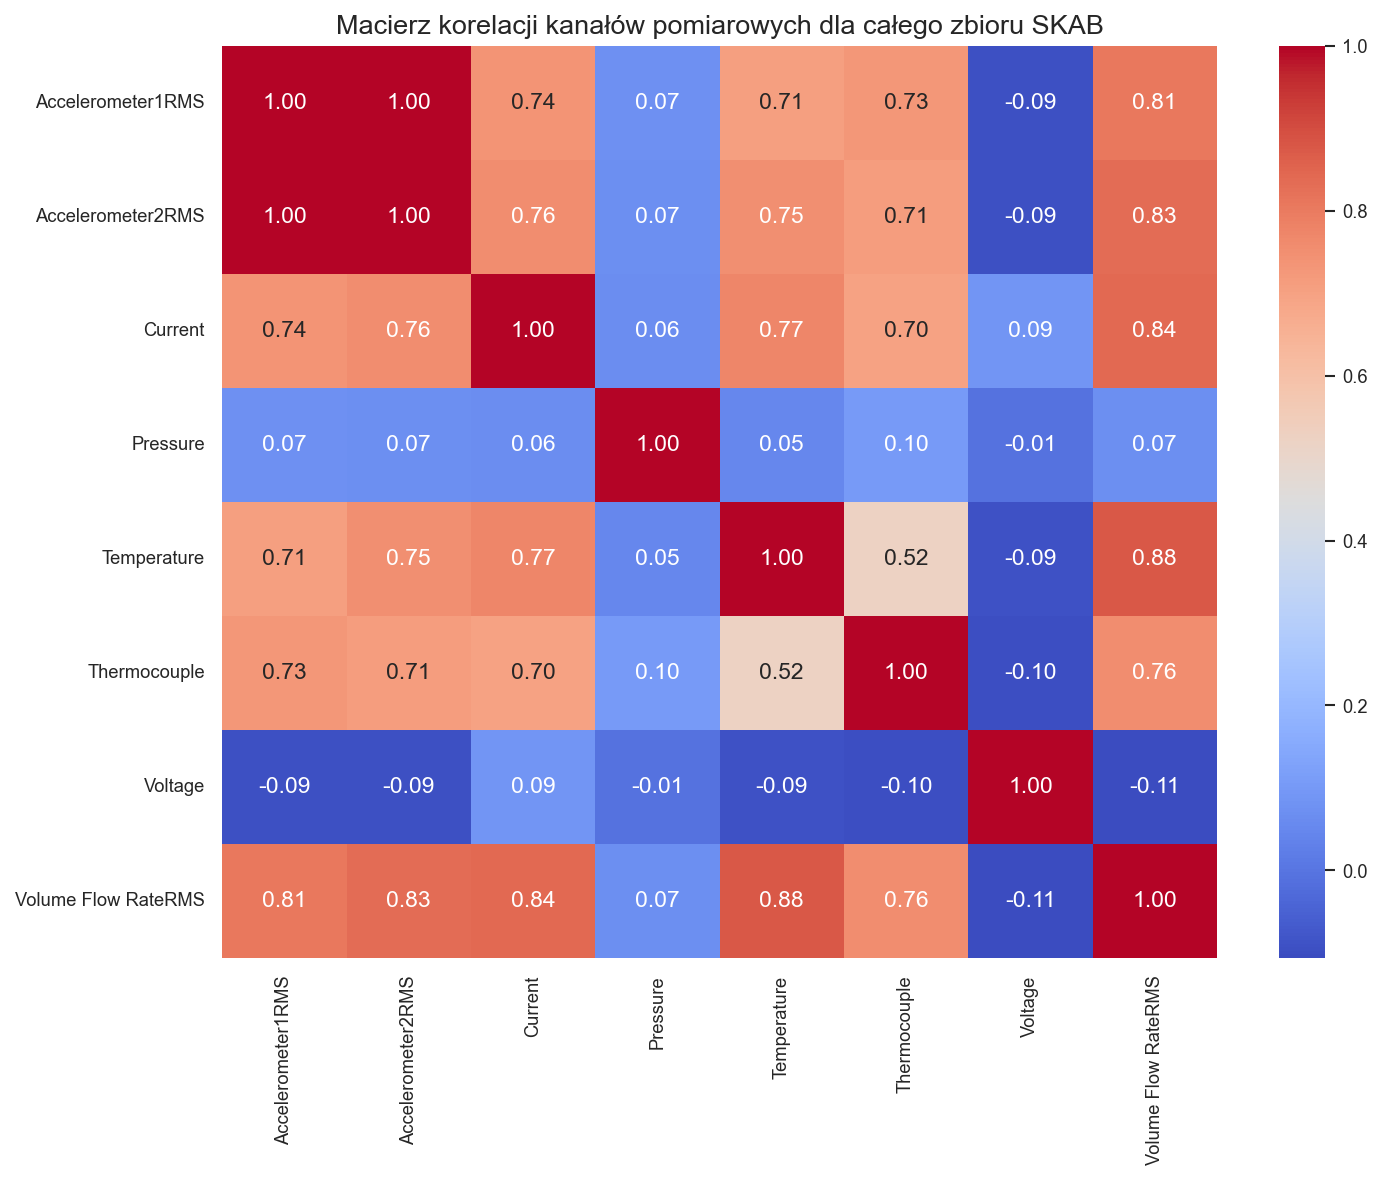

                     Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  \
Accelerometer1RMS                 1.00               1.00     0.74      0.07   
Accelerometer2RMS                 1.00               1.00     0.76      0.07   
Current                           0.74               0.76     1.00      0.06   
Pressure                          0.07               0.07     0.06      1.00   
Temperature                       0.71               0.75     0.77      0.05   
Thermocouple                      0.73               0.71     0.70      0.10   
Voltage                          -0.09              -0.09     0.09     -0.01   
Volume Flow RateRMS               0.81               0.83     0.84      0.07   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
Accelerometer1RMS           0.71          0.73    -0.09                 0.81  
Accelerometer2RMS           0.75          0.71    -0.09                 0.83  
Current                     0.77          

In [14]:
# Połączenie wszystkich eksperymentów

all_data = pd.concat(list_of_df, ignore_index=True)

corr_matrix = all_data[sensor_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Macierz korelacji kanałów pomiarowych dla całego zbioru SKAB')
plt.tight_layout()
plt.show()

print(corr_matrix.round(2))

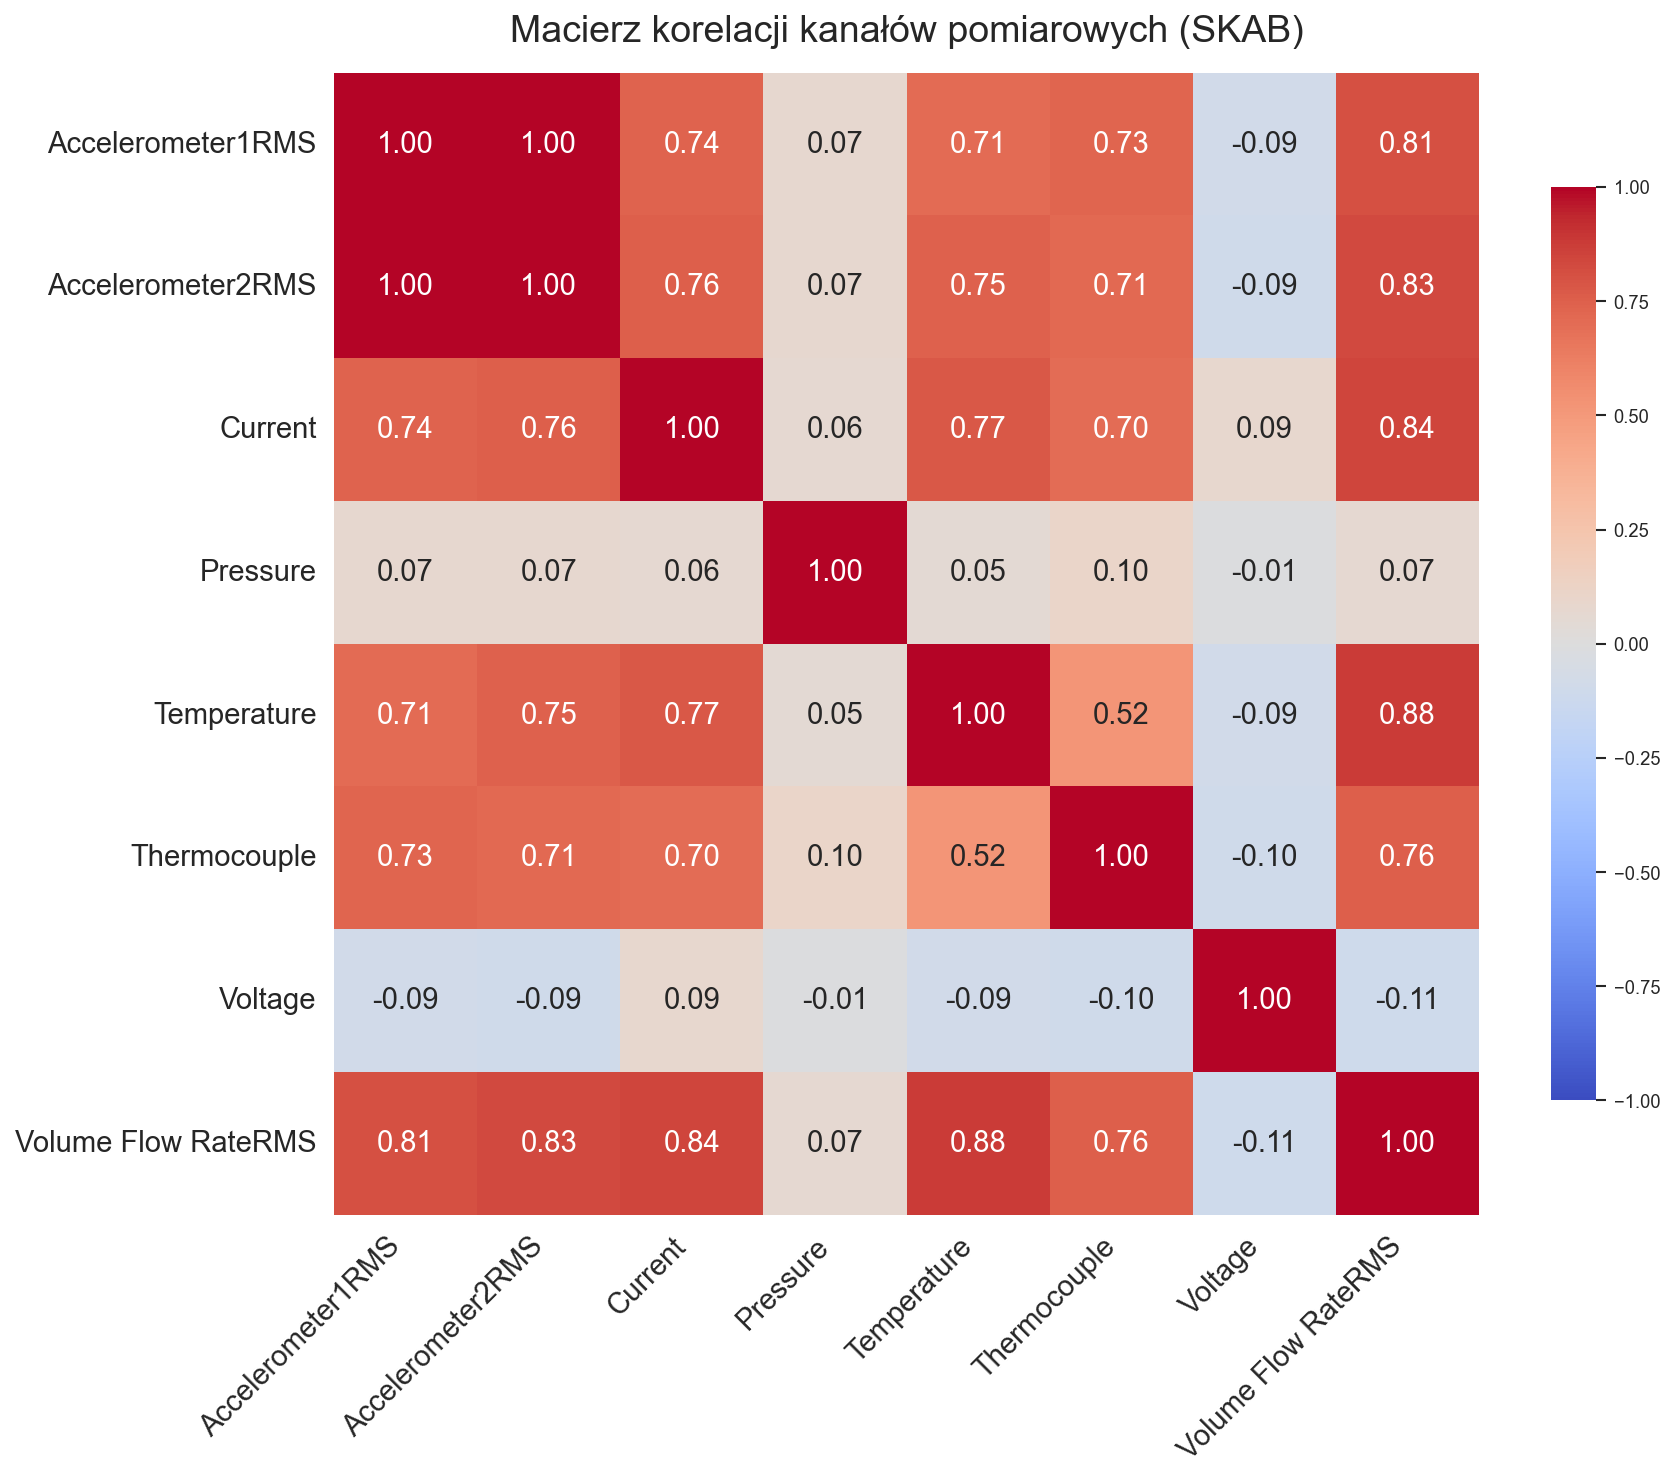

                     Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  \
Accelerometer1RMS                 1.00               1.00     0.74      0.07   
Accelerometer2RMS                 1.00               1.00     0.76      0.07   
Current                           0.74               0.76     1.00      0.06   
Pressure                          0.07               0.07     0.06      1.00   
Temperature                       0.71               0.75     0.77      0.05   
Thermocouple                      0.73               0.71     0.70      0.10   
Voltage                          -0.09              -0.09     0.09     -0.01   
Volume Flow RateRMS               0.81               0.83     0.84      0.07   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
Accelerometer1RMS           0.71          0.73    -0.09                 0.81  
Accelerometer2RMS           0.75          0.71    -0.09                 0.83  
Current                     0.77          

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

all_data = pd.concat(list_of_df, ignore_index=True)

corr_matrix = all_data[sensor_columns].corr()

plt.figure(figsize=(12, 10))  # 🔥 większa figura

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 14},   # 🔥 większe liczby w komórkach
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"shrink": 0.8}  # 🔥 trochę mniejszy pasek koloru
)

plt.title(
    'Macierz korelacji kanałów pomiarowych (SKAB)',
    fontsize=18,
    pad=15
)

plt.xticks(fontsize=14, rotation=45, ha='right')  # 🔥 czytelność osi X
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

print(corr_matrix.round(2))

In [16]:
(all_data['Accelerometer1RMS']
 - all_data['Accelerometer2RMS']).describe()

count    37401.000000
mean        -0.027988
std          0.019977
min         -0.133643
25%         -0.046559
50%         -0.013970
75%         -0.012824
max          0.000248
dtype: float64

11. Histogramy kanałów pomiarowych

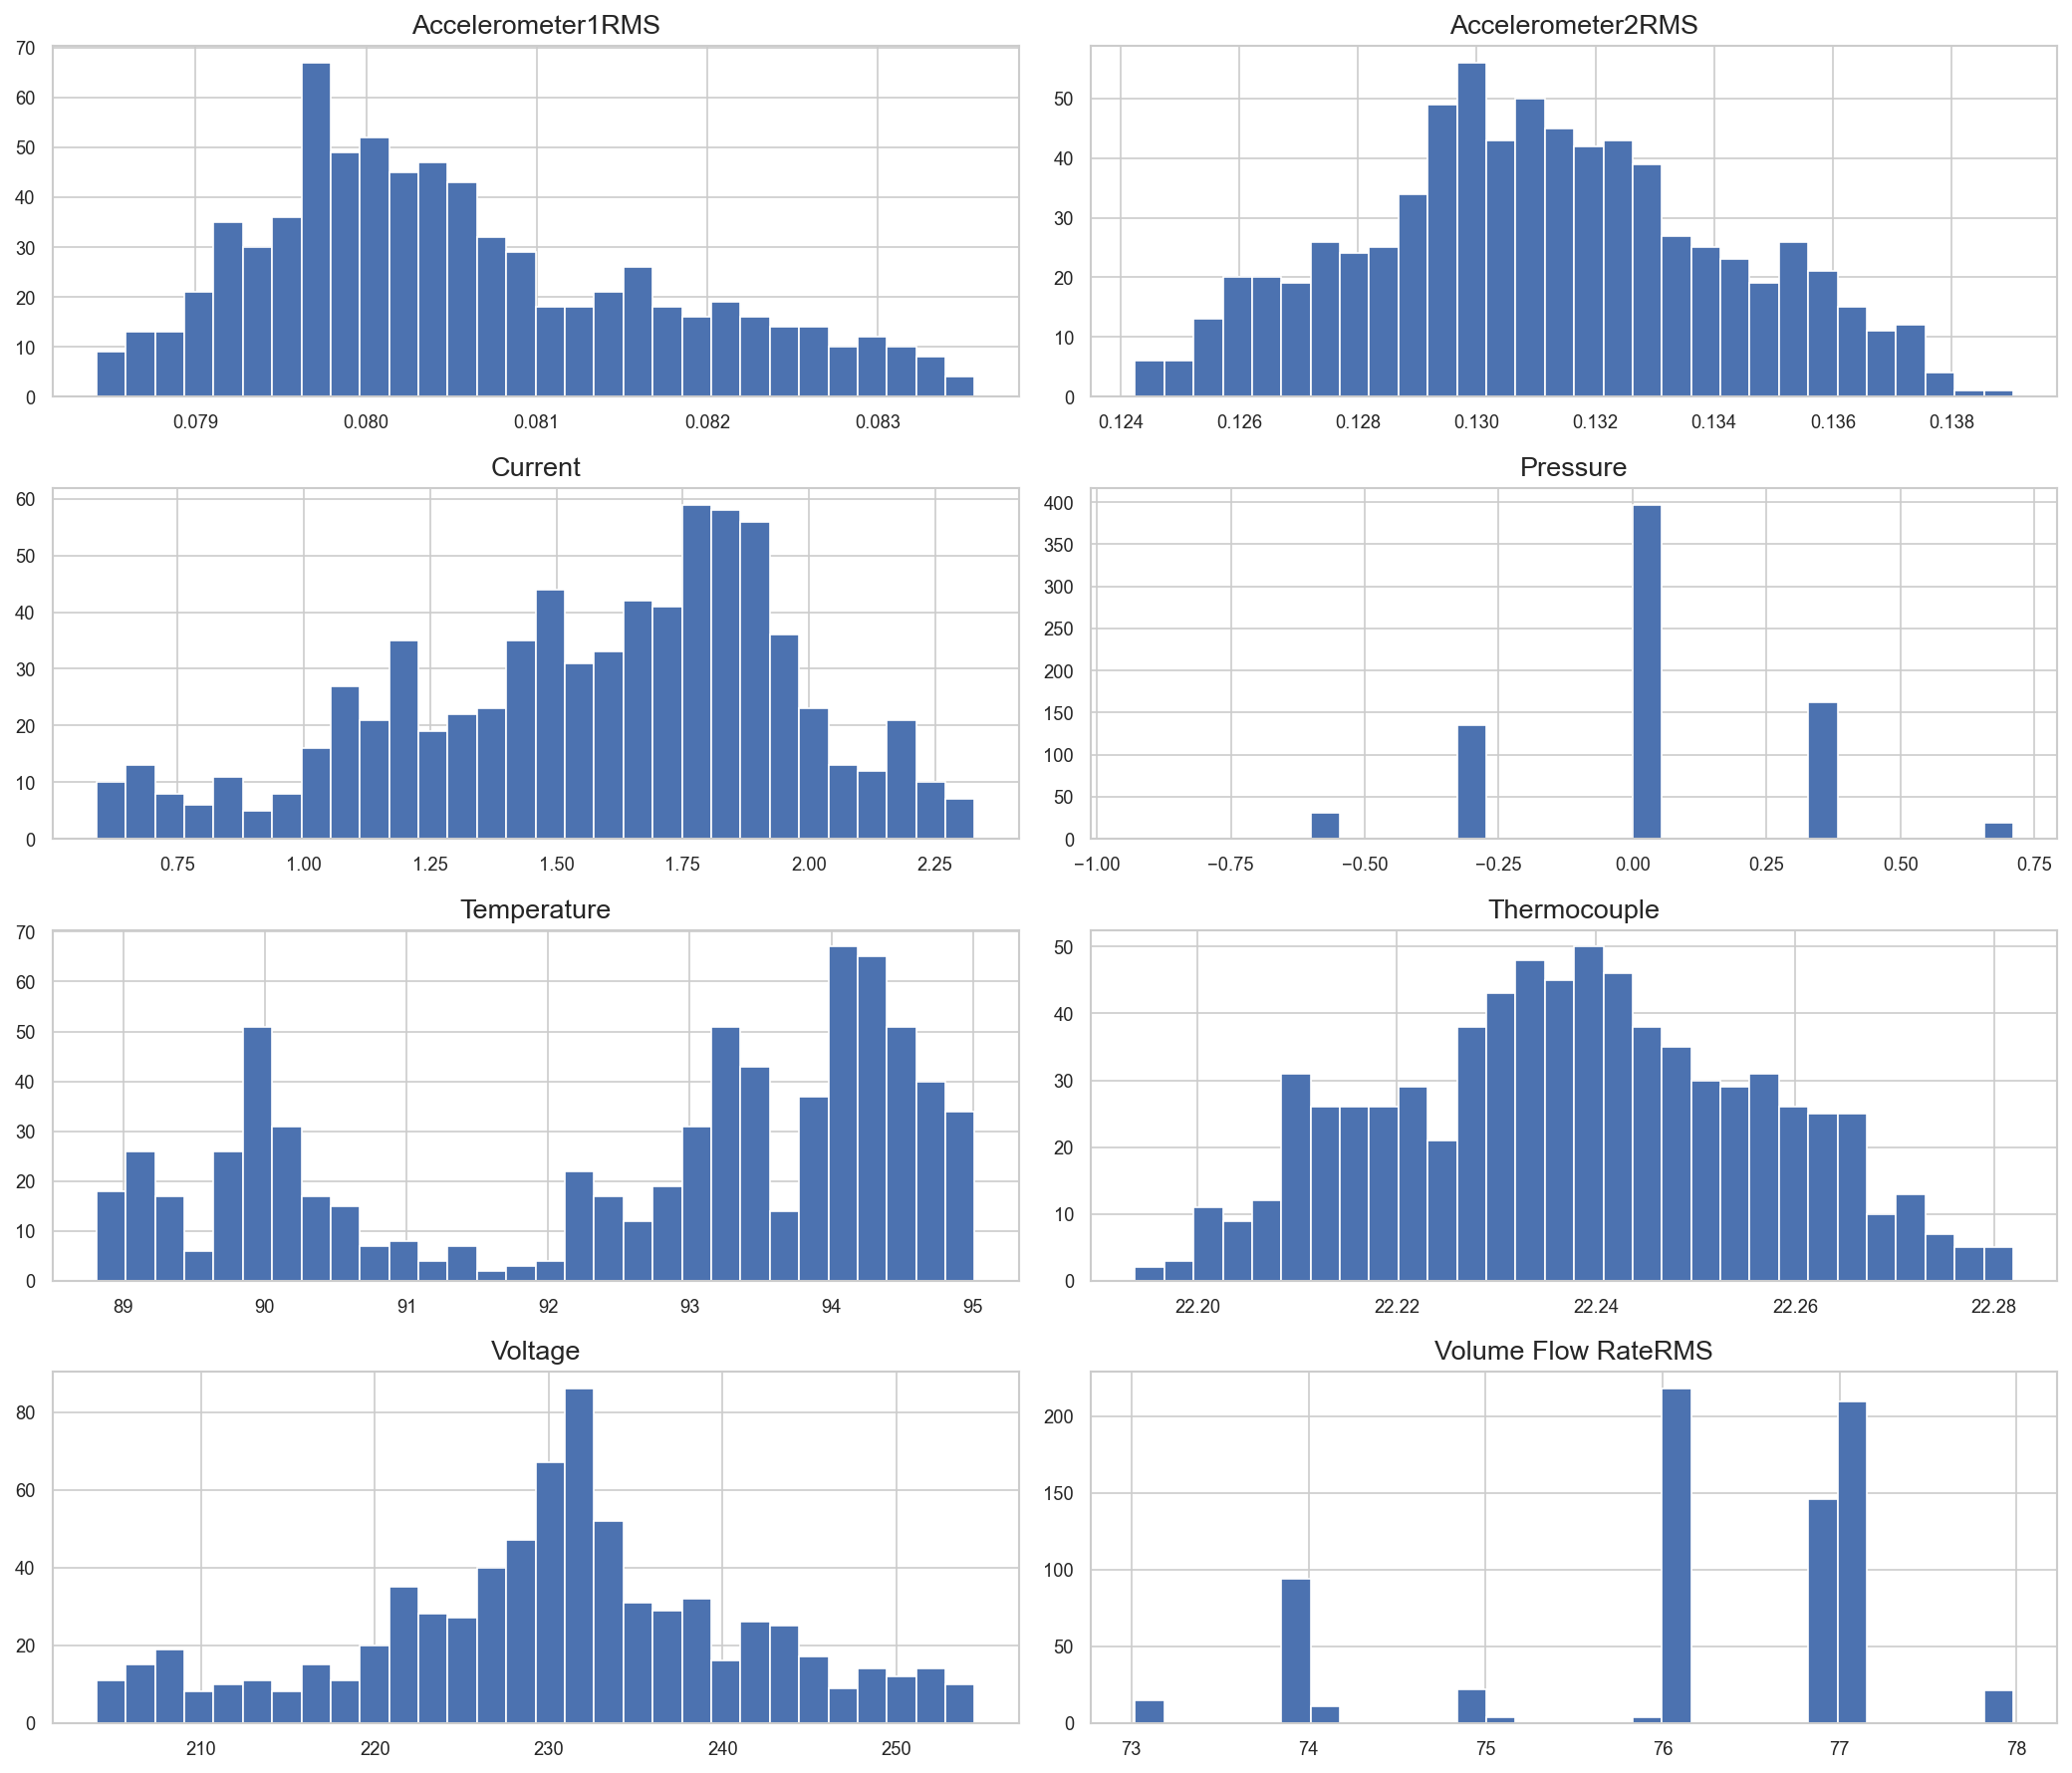

In [17]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 12)
)

axes = axes.flatten()

for i, column in enumerate(sensor_columns):

    axes[i].hist(
        example_df[column],
        bins=30
    )

    axes[i].set_title(column)

plt.tight_layout()

plt.savefig(
    f'{FIGURES_DIR}/sensor_histograms.png',
    bbox_inches='tight'
)

plt.show()

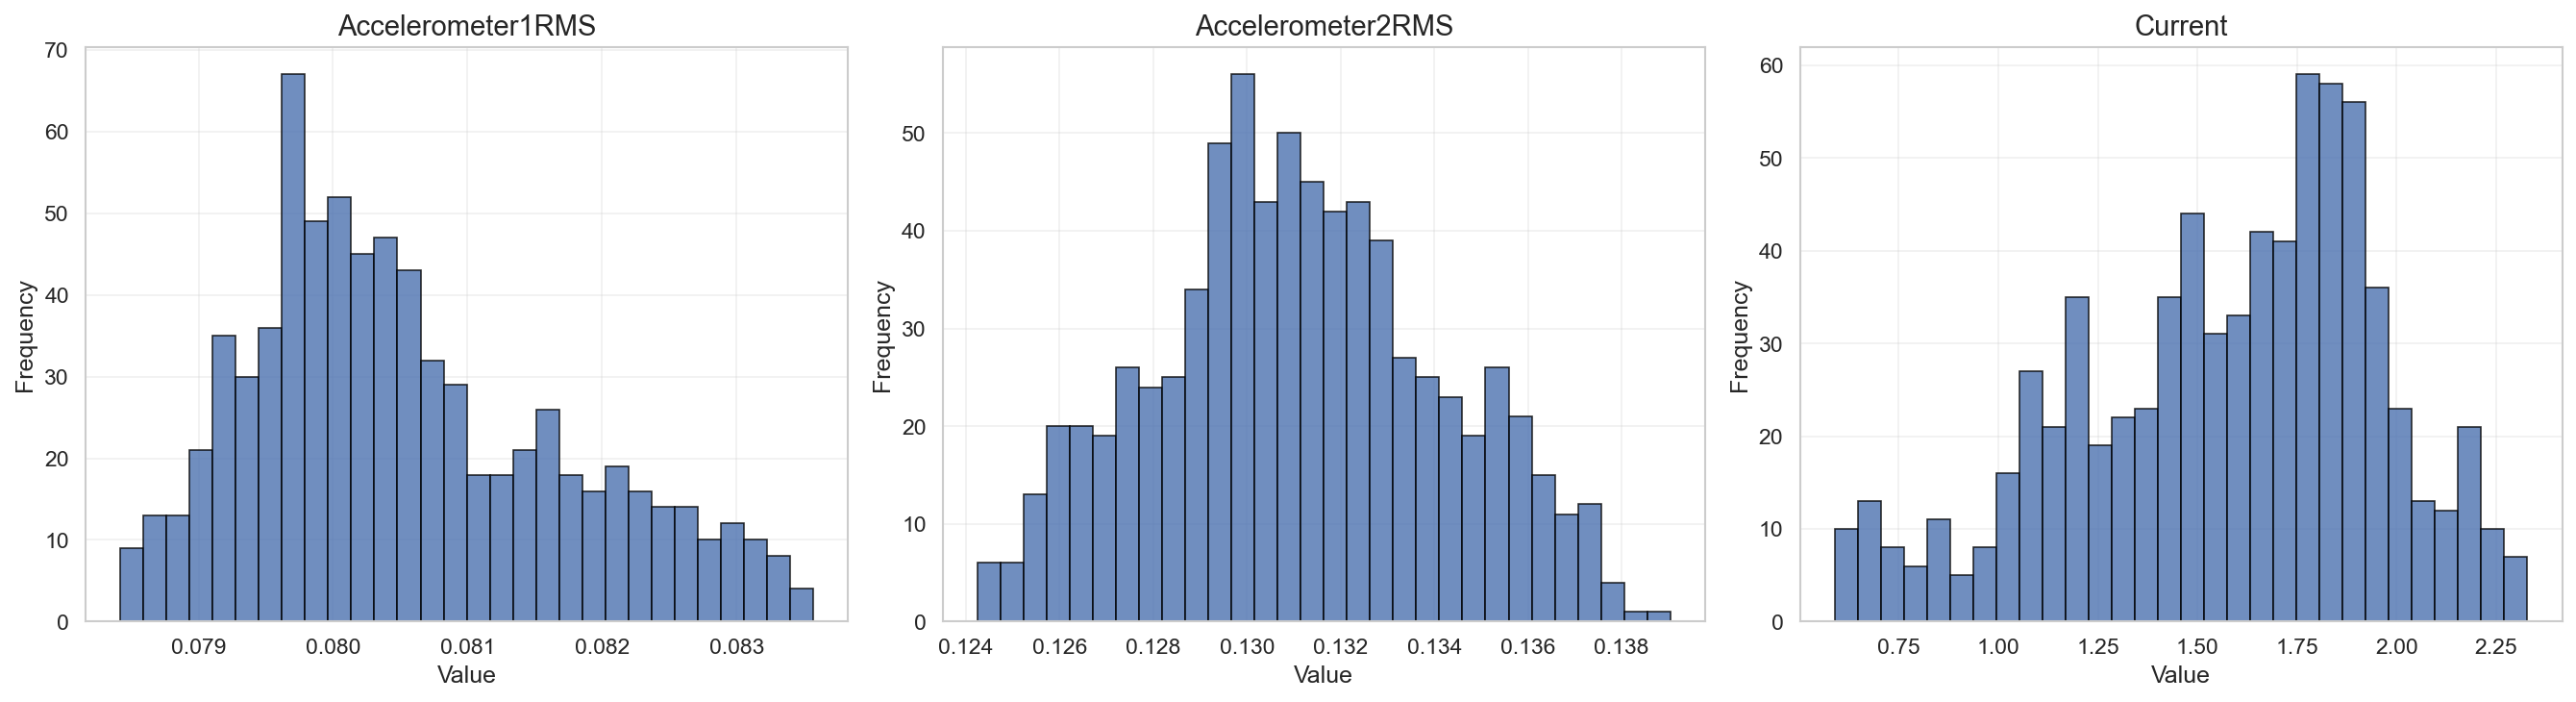

In [18]:
import matplotlib.pyplot as plt

selected_columns = sensor_columns[:3]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for i, column in enumerate(selected_columns):

    axes[i].hist(
        example_df[column],
        bins=30,
        edgecolor='black',
        alpha=0.8
    )

    axes[i].set_title(column, fontsize=14)

    axes[i].set_xlabel("Value", fontsize=12)
    axes[i].set_ylabel("Frequency", fontsize=12)

    axes[i].tick_params(axis='both', labelsize=11)

    axes[i].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f'{FIGURES_DIR}/sensor_histograms.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

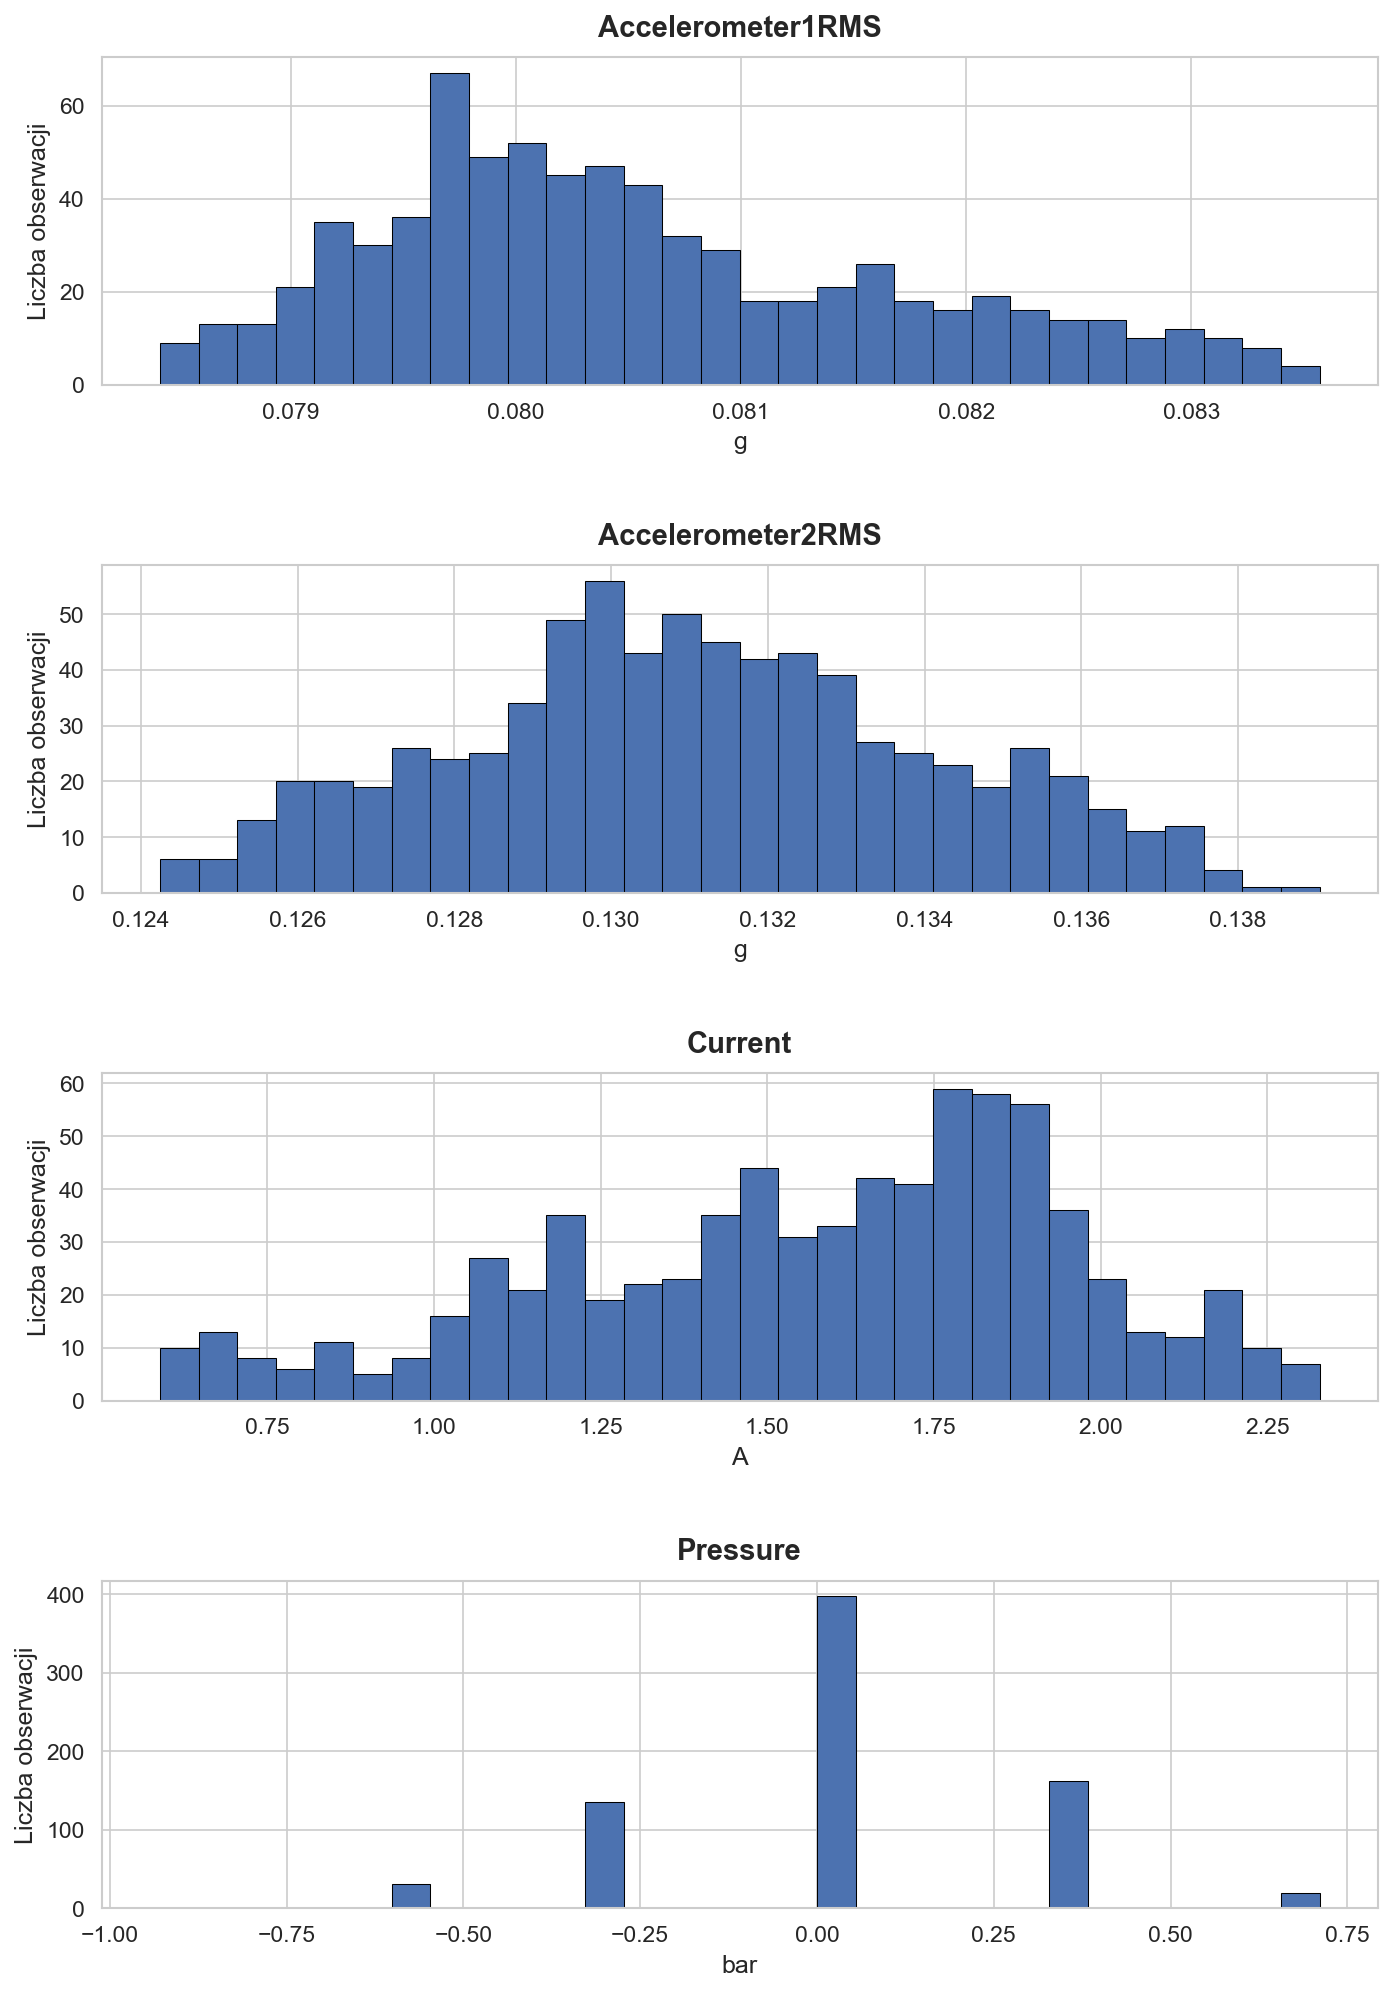

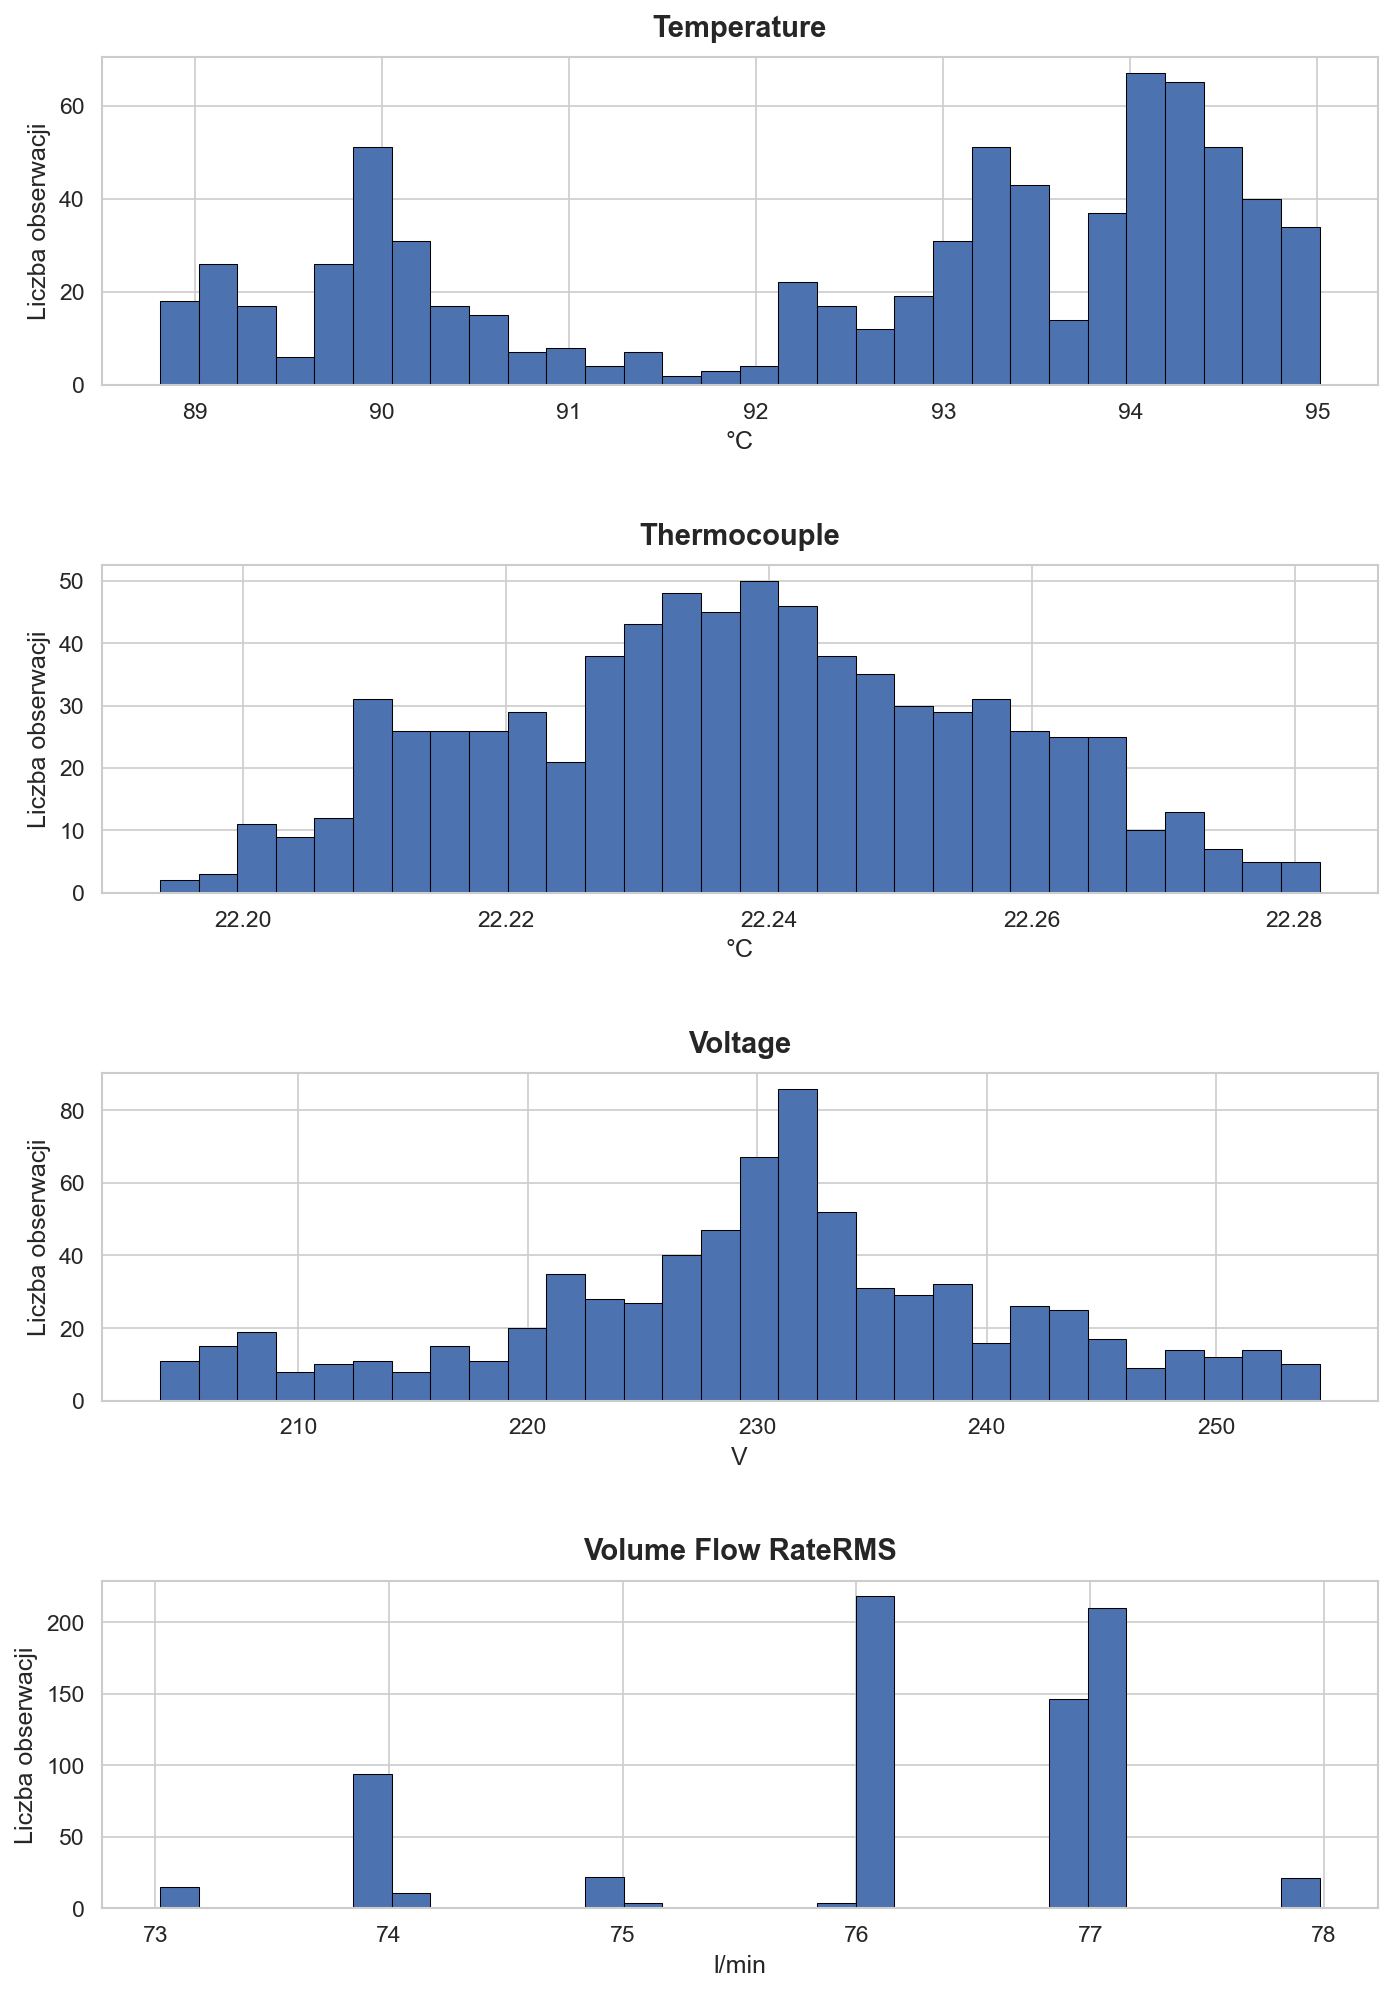

In [19]:
units = {
    'Accelerometer1RMS': 'g',
    'Accelerometer2RMS': 'g',
    'Current': 'A',
    'Pressure': 'bar',
    'Temperature': '°C',
    'Thermocouple': '°C',
    'Voltage': 'V',
    'Volume Flow RateRMS': 'l/min'
}

for part, columns_subset in enumerate([sensor_columns[:4], sensor_columns[4:]], start=1):
    fig, axes = plt.subplots(
        4, 1,
        figsize=(10, 14)  
    )
    for i, column in enumerate(columns_subset):
        axes[i].hist(
            example_df[column],
            bins=30,
            edgecolor='black',
            linewidth=0.5
        )
        axes[i].set_title(column, fontsize=14, fontweight='bold', pad=10)
        axes[i].set_xlabel(units[column], fontsize=12)
        axes[i].set_ylabel('Liczba obserwacji', fontsize=12)
        axes[i].tick_params(axis='both', labelsize=11)

    plt.tight_layout(pad=3.0)
    plt.savefig(
        f'{FIGURES_DIR}/histogram_part{part}.png',
        bbox_inches='tight',
        dpi=150
    )
    plt.show()

2. Przygotowanie danych do modeli

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    example_df.drop(['anomaly', 'changepoint'], axis=1),
    example_df[['anomaly', 'changepoint']],
    train_size=400,
    shuffle=False,
    random_state=0
)

print(X_train.shape)
print(X_test.shape)

(400, 8)
(345, 8)


13. Sliding window

In [21]:
import numpy as np


def create_sequences(values, time_steps):
    output = []

    for i in range(len(values) - time_steps + 1):
        output.append(values[i:(i + time_steps)])

    return np.stack(output)


TIME_STEPS = 30

X_train_seq = create_sequences(X_train.values, TIME_STEPS)

print(X_train_seq.shape)

(371, 30, 8)


In [22]:
anomaly_stats = []

for i, df in enumerate(list_of_df):

    anomaly_count = df['anomaly'].sum()

    anomaly_stats.append({
        'experiment': i + 1,
        'samples': len(df),
        'anomalies': anomaly_count,
        'anomaly_percent': round(
            100 * anomaly_count / len(df),
            2
        )
    })

anomaly_stats_df = pd.DataFrame(anomaly_stats)

anomaly_stats_df.head()

,experiment,samples,anomalies,anomaly_percent
0,1,745,188.0,25.23
1,2,1327,586.0,44.16
2,3,1190,451.0,37.90
3,4,1048,309.0,29.48
4,5,923,265.0,28.71


In [23]:
print(anomaly_stats_df.describe())

       experiment      samples   anomalies  anomaly_percent
count   34.000000    34.000000   34.000000        34.000000
mean    17.500000  1100.029412  384.323529        34.867353
std      9.958246   113.005091   61.386367         4.040974
min      1.000000   745.000000  188.000000        25.230000
25%      9.250000  1091.000000  386.500000        33.757500
50%     17.500000  1140.500000  399.000000        35.000000
75%     25.750000  1147.750000  402.750000        35.125000
max     34.000000  1327.000000  586.000000        49.230000


In [24]:
stats_df.to_latex(
    'sensor_statistics.tex',
    float_format="%.3f"
)

anomaly_stats_df.to_latex(
    'anomaly_statistics.tex',
    index=False,
    float_format="%.2f"
)

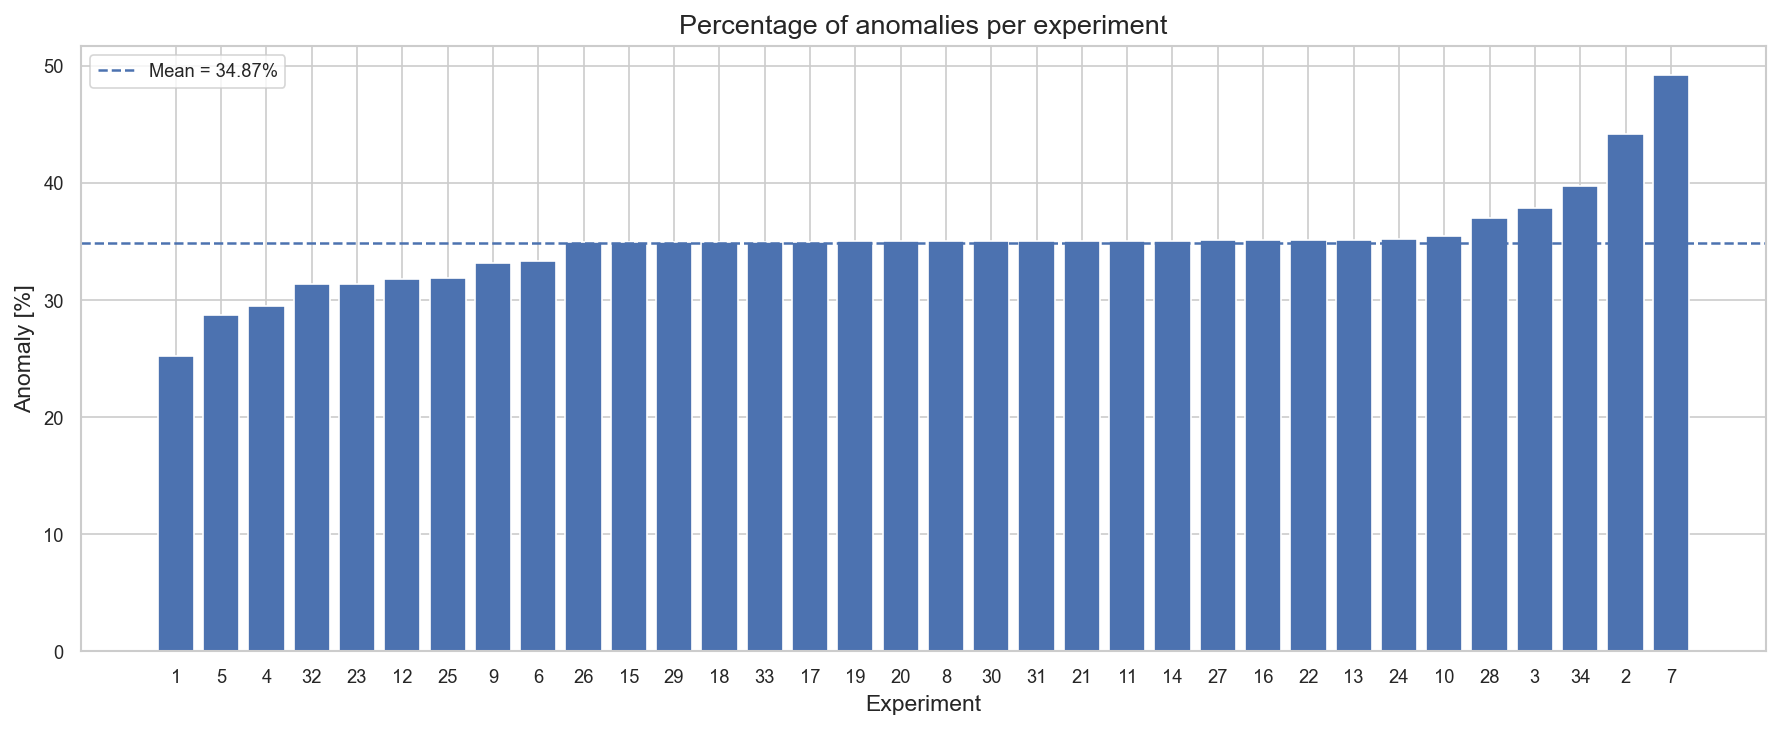

In [25]:
# 11. Odsetek anomalii w poszczególnych eksperymentach

stats = []

for i, df in enumerate(list_of_df):

    anomaly_percent = 100 * df['anomaly'].sum() / len(df)

    stats.append({
        'experiment': i + 1,
        'anomaly_percent': anomaly_percent
    })

stats_df = pd.DataFrame(stats)

stats_df = stats_df.sort_values('anomaly_percent')

plt.figure(figsize=(12,5))

plt.bar(
    stats_df['experiment'].astype(str),
    stats_df['anomaly_percent']
)

plt.axhline(
    stats_df['anomaly_percent'].mean(),
    linestyle='--',
    label=f"Mean = {stats_df['anomaly_percent'].mean():.2f}%"
)

plt.title('Percentage of anomalies per experiment')
plt.xlabel('Experiment')
plt.ylabel('Anomaly [%]')
plt.legend()

plt.tight_layout()



plt.show()

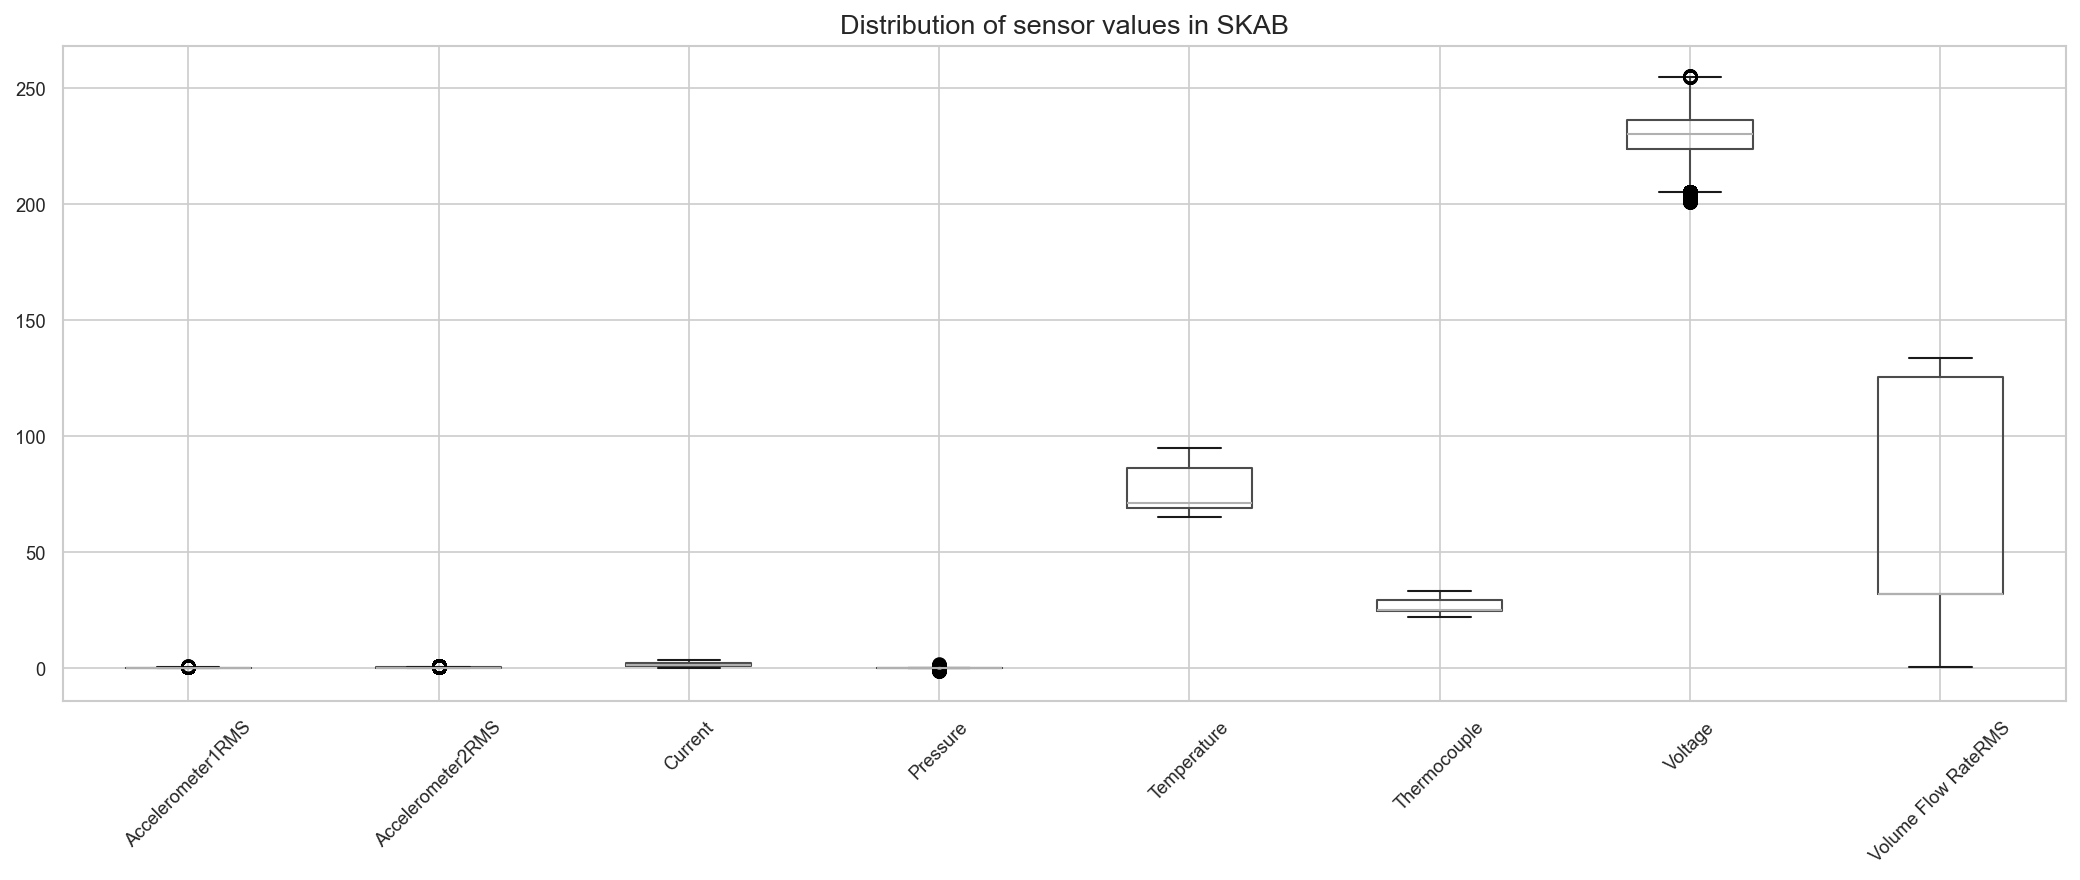

In [26]:
# 12. Boxploty kanałów pomiarowych

combined_df = pd.concat(
    list_of_df,
    ignore_index=True
)

sensor_columns = [
    col for col in combined_df.columns
    if col not in ['anomaly', 'changepoint']
]

plt.figure(figsize=(14,6))

combined_df[sensor_columns].boxplot(
    rot=45
)

plt.title('Distribution of sensor values in SKAB')

plt.tight_layout()


plt.show()

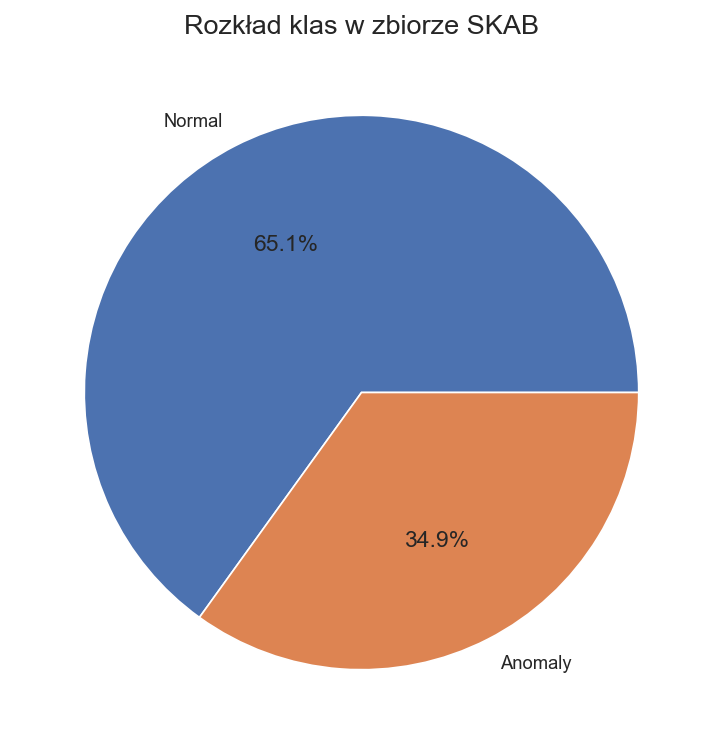

In [27]:
normal = all_samples - all_anomalies
anomaly = all_anomalies

plt.figure(figsize=(6,6))

plt.pie(
    [normal, anomaly],
    labels=['Normal', 'Anomaly'],
    autopct='%1.1f%%'
)

plt.title('Rozkład klas w zbiorze SKAB')
plt.show()

In [28]:
# Połączenie wszystkich eksperymentów w jedną tabelę

all_data = pd.concat(
    list_of_df,
    ignore_index=True
)

print(all_data.shape)

(37401, 10)


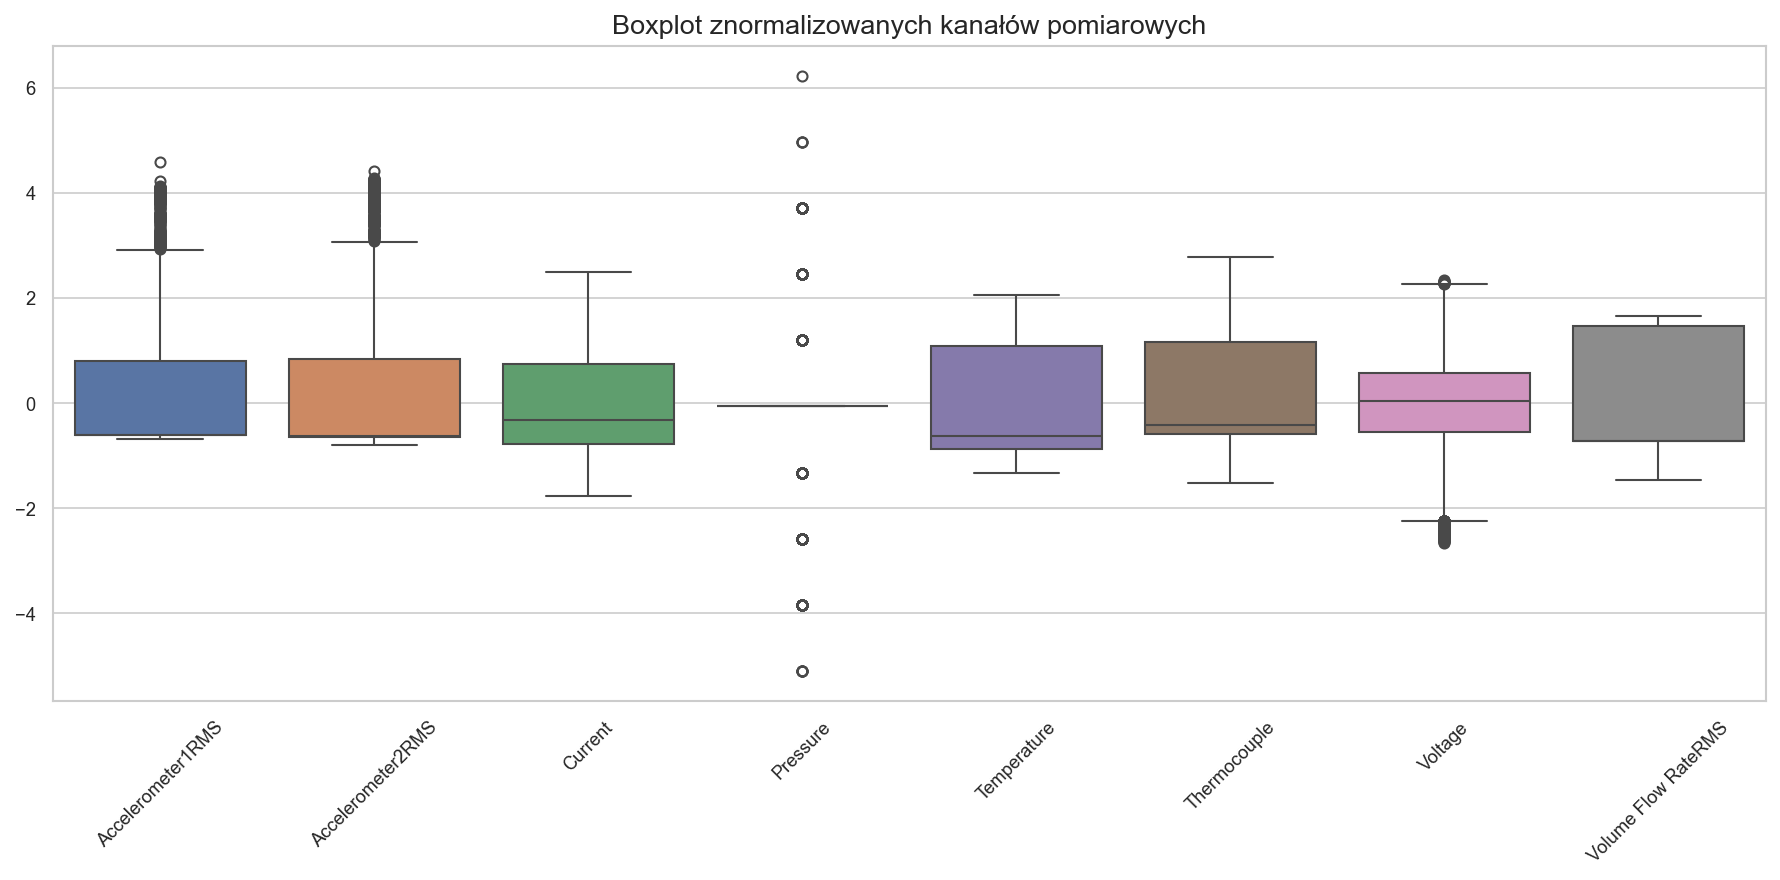

In [29]:
from sklearn.preprocessing import StandardScaler

scaled_data = pd.DataFrame(
    StandardScaler().fit_transform(
        all_data[sensor_columns]
    ),
    columns=sensor_columns
)

plt.figure(figsize=(12,6))
sns.boxplot(data=scaled_data)

plt.xticks(rotation=45)
plt.title('Boxplot znormalizowanych kanałów pomiarowych')
plt.tight_layout()
plt.show()